# 🎯 SCVD Violence Detection - الكود الكامل
### شغّل الـ Cells واحدة واحدة بالترتيب

In [2]:
# ============================================================
# ⚙️ الإعدادات - غيّر المسار بتاعك هنا بس
# ============================================================

DATASET_PATH = r"C:\Users\student\Desktop\ai_env\archive\SCVD\SCVD_converted_sec_split"  # ← غيّر ده بس

# باقي الإعدادات مش محتاج تغيّرها
CLASSES     = ['Normal', 'Violence', 'Weaponized']
NUM_FRAMES  = 16
IMG_SIZE    = 112
BATCH_SIZE  = 8
EPOCHS      = 20
LR          = 0.001
SAVE_PATH   = 'best_model.pth'

print('✅ الإعدادات جاهزة!')

✅ الإعدادات جاهزة!


## 📦 STEP 1: استكشاف الـ Dataset

In [9]:
import os
import cv2

# عدّ الفيديوهات
print('=' * 50)
print(f"{'Split':<10} {'Class':<15} {'Videos':>8}")
print('=' * 50)

for split in ['Train', 'Test']:
    total = 0
    for cls in CLASSES:
        path  = os.path.join(DATASET_PATH, split, cls)
        count = len(os.listdir(path))
        total += count
        print(f"{split:<10} {cls:<15} {count:>8}")
    print(f"{'':10} {'TOTAL':<15} {total:>8}")
    print('-' * 50)

# مواصفات أول فيديو
sample      = os.path.join(DATASET_PATH, 'Train', 'Normal')
first_video = os.path.join(sample, os.listdir(sample)[0])
cap         = cv2.VideoCapture(first_video)
fps         = cap.get(cv2.CAP_PROP_FPS)
frames      = cap.get(cv2.CAP_PROP_FRAME_COUNT)
w           = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
h           = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
cap.release()

print(f'\nمواصفات الفيديو:')
print(f'  FPS      : {fps}')
print(f'  Frames   : {frames}')
print(f'  Size     : {int(w)}x{int(h)}')
print(f'  Duration : {frames/fps:.2f} ثانية')
print('\n✅ الـ Dataset شغّال!')

Split      Class             Videos
Train      Normal               872
Train      Violence             970
Train      Weaponized           832
           TOTAL               2674
--------------------------------------------------
Test       Normal               169
Test       Violence             118
Test       Weaponized           190
           TOTAL                477
--------------------------------------------------

مواصفات الفيديو:
  FPS      : 30.0
  Frames   : 30.0
  Size     : 1280x720
  Duration : 1.00 ثانية

✅ الـ Dataset شغّال!


## 📦 STEP 2: بناء الـ Dataset Class

In [4]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# الـ Transforms
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class SCVDDataset(Dataset):
    def __init__(self, root_path, split='Train'):
        self.samples = []
        for label, cls in enumerate(CLASSES):
            folder = os.path.join(root_path, split, cls)
            for video_file in os.listdir(folder):
                if video_file.endswith('.avi'):
                    self.samples.append((os.path.join(folder, video_file), label))
        print(f'✅ {split}: {len(self.samples)} فيديو')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        video_path, label = self.samples[idx]
        return self._load_frames(video_path), label

    def _load_frames(self, video_path):
        cap         = cv2.VideoCapture(video_path)
        total       = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        indices     = set([int(i * total / NUM_FRAMES) for i in range(NUM_FRAMES)])
        frames_list = []
        for i in range(total):
            ret, frame = cap.read()
            if not ret:
                break
            if i in indices:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frames_list.append(transform(frame))
                if len(frames_list) == NUM_FRAMES:
                    break
        cap.release()
        while len(frames_list) < NUM_FRAMES:
            frames_list.append(torch.zeros(3, IMG_SIZE, IMG_SIZE))
        return torch.stack(frames_list)

# حمّل الـ Data
train_dataset = SCVDDataset(DATASET_PATH, split='Train')
test_dataset  = SCVDDataset(DATASET_PATH, split='Test')
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# اتحقق من شكل الـ batch
frames, labels = next(iter(train_loader))
print(f'\nشكل الـ batch:')
print(f'  Frames : {frames.shape}')
print(f'  Labels : {labels}')
print('\n✅ الـ Dataset جاهز!')

✅ Train: 2674 فيديو
✅ Test: 477 فيديو

شكل الـ batch:
  Frames : torch.Size([8, 16, 3, 112, 112])
  Labels : tensor([1, 1, 1, 2, 1, 1, 1, 0])

✅ الـ Dataset جاهز!


## 🏗️ STEP 3: بناء الـ Model

In [5]:
import torch.nn as nn
from torchvision import models

class CNNLSTMModel(nn.Module):
    def __init__(self):
        super(CNNLSTMModel, self).__init__()
        resnet       = models.resnet18(pretrained=True)
        self.cnn     = nn.Sequential(*list(resnet.children())[:-1])
        self.lstm    = nn.LSTM(512, 256, num_layers=2, batch_first=True, dropout=0.3)
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, len(CLASSES))
        )

    def forward(self, x):
        b, t, C, H, W = x.shape
        x = x.view(b * t, C, H, W)
        with torch.no_grad():
            features = self.cnn(x)
        features    = features.view(b, t, -1)
        lstm_out, _ = self.lstm(features)
        return self.classifier(lstm_out[:, -1, :])

# جهّز الـ Device والـ Model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = CNNLSTMModel().to(device)

print(f'✅ الـ Model شغّال على: {device}')
print(f'   GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')

✅ الـ Model شغّال على: cuda
   GPU: NVIDIA RTX 2000 Ada Generation


c:\Users\student\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\student\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## 🚀 STEP 4: التدريب

Epoch 01/20 | Train Loss: 1.0076 Acc: 46.6% | Test Loss: 0.6712 Acc: 60.8%
  💾 أفضل نموذج اتحفظ! Accuracy: 60.8%
Epoch 02/20 | Train Loss: 0.8769 Acc: 56.2% | Test Loss: 0.5820 Acc: 67.3%
  💾 أفضل نموذج اتحفظ! Accuracy: 67.3%
Epoch 03/20 | Train Loss: 0.8193 Acc: 59.7% | Test Loss: 0.4705 Acc: 86.0%
  💾 أفضل نموذج اتحفظ! Accuracy: 86.0%
Epoch 04/20 | Train Loss: 0.7148 Acc: 68.8% | Test Loss: 0.3388 Acc: 92.5%
  💾 أفضل نموذج اتحفظ! Accuracy: 92.5%
Epoch 05/20 | Train Loss: 0.6746 Acc: 70.0% | Test Loss: 0.3281 Acc: 88.1%
Epoch 06/20 | Train Loss: 0.6251 Acc: 75.4% | Test Loss: 0.2275 Acc: 97.3%
  💾 أفضل نموذج اتحفظ! Accuracy: 97.3%
Epoch 07/20 | Train Loss: 0.5211 Acc: 80.1% | Test Loss: 0.2214 Acc: 91.8%
Epoch 08/20 | Train Loss: 0.4024 Acc: 84.5% | Test Loss: 0.1173 Acc: 95.6%
Epoch 09/20 | Train Loss: 0.3567 Acc: 86.6% | Test Loss: 0.0914 Acc: 97.3%
Epoch 10/20 | Train Loss: 0.3607 Acc: 86.5% | Test Loss: 0.0955 Acc: 96.9%
Epoch 11/20 | Train Loss: 0.3323 Acc: 88.6% | Test Loss: 0.0

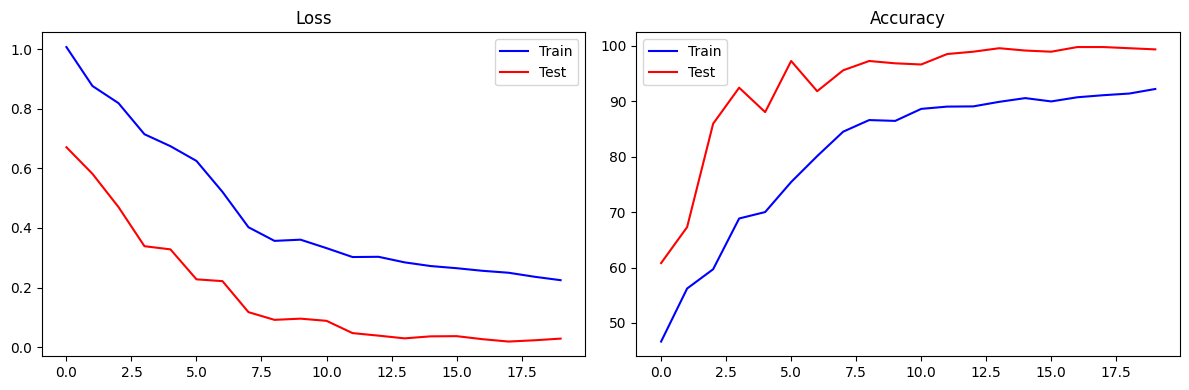

In [6]:
from torch.optim import Adam
from torch.optim.lr_scheduler import StepLR
import matplotlib.pyplot as plt

criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=LR)
scheduler = StepLR(optimizer, step_size=7, gamma=0.1)

train_losses, test_losses = [], []
train_accs,   test_accs   = [], []
best_accuracy = 0.0

for epoch in range(1, EPOCHS + 1):
    # ---- Training ----
    model.train()
    t_loss, correct, total = 0, 0, 0
    for frames, labels in train_loader:
        frames, labels = frames.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(frames)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        t_loss  += loss.item()
        correct += outputs.max(1)[1].eq(labels).sum().item()
        total   += labels.size(0)
    train_loss = t_loss / len(train_loader)
    train_acc  = 100. * correct / total

    # ---- Evaluation ----
    model.eval()
    v_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for frames, labels in test_loader:
            frames, labels = frames.to(device), labels.to(device)
            outputs = model(frames)
            loss    = criterion(outputs, labels)
            v_loss  += loss.item()
            correct += outputs.max(1)[1].eq(labels).sum().item()
            total   += labels.size(0)
    test_loss = v_loss / len(test_loader)
    test_acc  = 100. * correct / total

    scheduler.step()
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f'Epoch {epoch:02d}/{EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.1f}% | Test Loss: {test_loss:.4f} Acc: {test_acc:.1f}%')

    if test_acc > best_accuracy:
        best_accuracy = test_acc
        torch.save(model.state_dict(), SAVE_PATH)
        print(f'  💾 أفضل نموذج اتحفظ! Accuracy: {best_accuracy:.1f}%')

print(f'\n✅ التدريب خلص! أفضل دقة: {best_accuracy:.1f}%')

# ارسم الـ Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, label='Train', color='blue')
ax1.plot(test_losses,  label='Test',  color='red')
ax1.set_title('Loss'); ax1.legend()
ax2.plot(train_accs, label='Train', color='blue')
ax2.plot(test_accs,  label='Test',  color='red')
ax2.set_title('Accuracy'); ax2.legend()
plt.tight_layout()
plt.savefig('training_curves.png')
plt.show()

## 📊 STEP 5: التقييم والنتايج

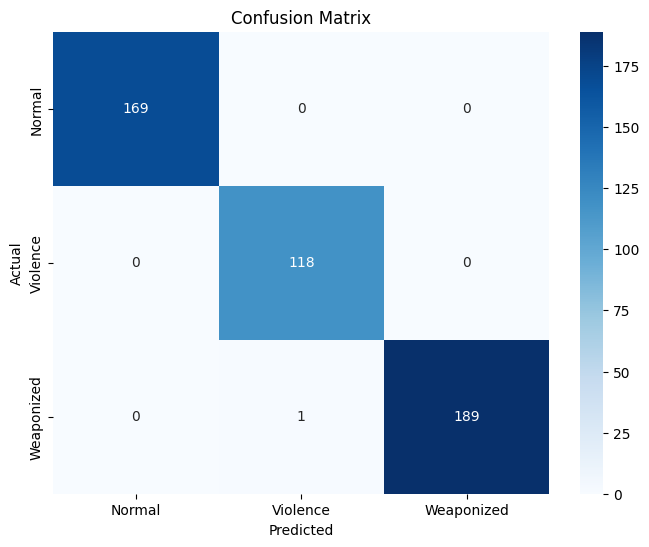

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       169
    Violence       0.99      1.00      1.00       118
  Weaponized       1.00      0.99      1.00       190

    accuracy                           1.00       477
   macro avg       1.00      1.00      1.00       477
weighted avg       1.00      1.00      1.00       477



In [7]:
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# حمّل أفضل نموذج
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for frames, labels in test_loader:
        frames  = frames.to(device)
        outputs = model(frames)
        all_preds.extend(outputs.max(1)[1].cpu().numpy())
        all_labels.extend(labels.numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES, cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png')
plt.show()

# Classification Report
print('=' * 50)
print(classification_report(all_labels, all_preds, target_names=CLASSES))

## 🎯 STEP 6: جرّب على فيديو جديد

In [8]:
def predict_video(video_path):
    cap         = cv2.VideoCapture(video_path)
    total       = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    indices     = set([int(i * total / NUM_FRAMES) for i in range(NUM_FRAMES)])
    frames_list = []
    for i in range(total):
        ret, frame = cap.read()
        if not ret: break
        if i in indices:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames_list.append(transform(frame))
            if len(frames_list) == NUM_FRAMES: break
    cap.release()
    while len(frames_list) < NUM_FRAMES:
        frames_list.append(torch.zeros(3, IMG_SIZE, IMG_SIZE))

    tensor = torch.stack(frames_list).unsqueeze(0).to(device)
    with torch.no_grad():
        probs      = torch.softmax(model(tensor), dim=1)[0]
        pred_class = probs.argmax().item()

    print(f'\n🎬 الفيديو: {video_path}')
    print(f'📌 التصنيف: {CLASSES[pred_class]} ({probs[pred_class]*100:.1f}%)')
    for i, cls in enumerate(CLASSES):
        bar = '█' * int(probs[i] * 30)
        print(f'   {cls:<12}: {bar:<30} {probs[i]*100:.1f}%')

# جرّب على فيديو من الـ Test
sample_video = os.path.join(DATASET_PATH, 'Test', 'Violence', os.listdir(os.path.join(DATASET_PATH, 'Test', 'Violence'))[0])
predict_video(sample_video)


🎬 الفيديو: C:\Users\student\Desktop\ai_env\archive\SCVD\SCVD_converted_sec_split\Test\Violence\Violence-Test001.avi
📌 التصنيف: Violence (98.9%)
   Normal      :                                0.1%
   Violence    : █████████████████████████████  98.9%
   Weaponized  :                                0.9%
